# Module 8 — Experimental Design, Power & the Pitfalls of Testing

**Statistics Deep Dive · Notebook 8 of 13**

Most statistical disasters do not happen in the analysis — they are built into the study before the first data point arrives, or sneak in through innocent-looking habits ("let's check whether it is significant yet"). This module is about **getting the design right** and recognising the classic traps.

### 🎯 Learning goals
After this module you can …
1. explain why **randomisation** beats any observational comparison, and what a **confounder** is,
2. recognise and resolve **Simpson's paradox**,
3. run a **power analysis** and plan sample sizes — and explain why underpowered studies exaggerate effects,
4. control error rates under **multiple testing** (Bonferroni, Holm, Benjamini–Hochberg),
5. quantify the damage done by **peeking** at running experiments and name the remedies,
6. reduce variance with **blocking / CUPED**, and spot **regression to the mean**.

### 🗺️ Contents
1. Observational vs. experimental data · 2. Simpson's paradox · 3. Power & sample size · 4. The winner's curse · 5. Multiple testing · 6. Peeking · 7. Variance reduction (CUPED) · 8. Regression to the mean · 9. Experiment checklist · 10. Exercises · 11. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.multitest import multipletests

---
## 1. Observational vs. experimental data — why randomise?

In an **observational study** we watch who happens to get the treatment. In an **experiment** *we* assign it. The difference is everything: in observational data the treated and untreated groups usually differ in many other ways — and any of those differences (**confounders**) can create, hide or reverse the apparent effect.

**Randomisation** cuts every arrow pointing *into* the treatment: a coin flip cannot be influenced by disease severity, motivation, income or anything else, measured **or unmeasured**. The groups become comparable *on average* in all respects, so a difference in outcomes can only come from the treatment (or chance — which the test quantifies).

**Simulation.** A drug truly improves a recovery score by **+5 points**. In the observational world doctors give it preferentially to sicker patients.

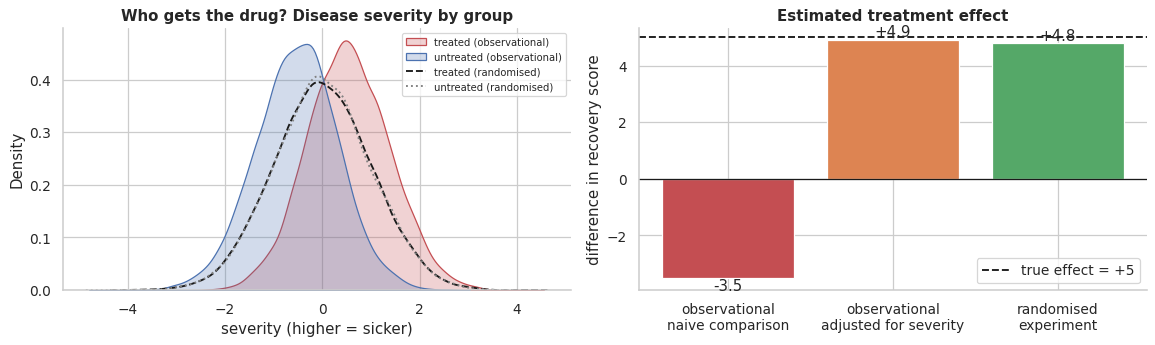

In [2]:
n = 20_000
severity = rng.normal(0, 1, n)
treated_obs = rng.random(n) < 1 / (1 + np.exp(-1.5 * severity))       # observational: sicker patients are treated more often
treated_rct = rng.random(n) < .5                                       # experiment: a coin decides
outcome = lambda treated: 60 + 5 * treated - 8 * severity + rng.normal(0, 10, n)      # true effect = +5
y_obs, y_rct = outcome(treated_obs), outcome(treated_rct)

naive = y_obs[treated_obs].mean() - y_obs[~treated_obs].mean()
X = np.column_stack([np.ones(n), treated_obs, severity])               # adjust for the confounder by regression (Module 10)
adjusted = np.linalg.lstsq(X, y_obs, rcond=None)[0][1]
rct = y_rct[treated_rct].mean() - y_rct[~treated_rct].mean()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(severity[treated_obs], ax=a1, color=C[3], fill=True, label="treated (observational)"); sns.kdeplot(severity[~treated_obs], ax=a1, color=C[0], fill=True, label="untreated (observational)")
sns.kdeplot(severity[treated_rct], ax=a1, color="k", ls="--", label="treated (randomised)"); sns.kdeplot(severity[~treated_rct], ax=a1, color="grey", ls=":", label="untreated (randomised)")
a1.set(title="Who gets the drug? Disease severity by group", xlabel="severity (higher = sicker)"); a1.legend(fontsize=8)
bars = a2.bar(["observational\nnaive comparison", "observational\nadjusted for severity", "randomised\nexperiment"], [naive, adjusted, rct], color=[C[3], C[1], C[2]])
a2.bar_label(bars, fmt="%+.1f"); a2.axhline(5, color="k", ls="--", label="true effect = +5"); a2.axhline(0, color="k", lw=1)
a2.set(title="Estimated treatment effect", ylabel="difference in recovery score"); a2.legend()
plt.tight_layout(); plt.show()

**Reading the figure.** In the observational data the treated are much sicker to begin with, so the naive comparison makes a helpful drug look **harmful**. Adjusting for severity repairs the estimate — but only because we *measured* the confounder and modelled it correctly. In real life you never know whether you have measured them all. Randomisation needs no such luck: the dashed severity curves are identical by construction.

| | Observational study | Randomised experiment |
|---|---|---|
| Treatment assigned by | self-selection, doctors, circumstances | chance |
| Groups comparable? | only on variables you adjust for | on everything, on average |
| Supports causal claims? | only with strong, untestable assumptions | yes |
| When to use | experiment impossible or unethical (smoking, recessions) | whenever you can |

---
## 2. Simpson's paradox — when the whole contradicts all of its parts

A trend that appears in every subgroup can **reverse** when the subgroups are pooled — if group sizes are unbalanced and a lurking variable drives both group membership and outcome.

**Real data — kidney stone treatments (Charig et al., *BMJ* 1986).** Treatment A is open surgery, B is a less invasive keyhole procedure.

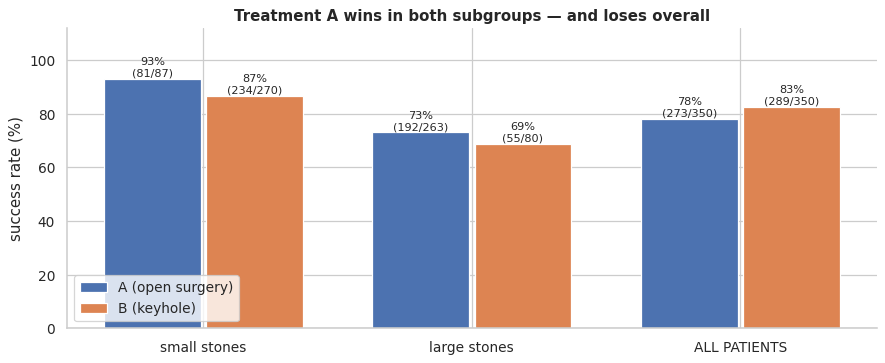

In [3]:
ks = pd.DataFrame({"stone size": ["small", "small", "large", "large"], "treatment": ["A (open surgery)", "B (keyhole)"] * 2,
                   "success": [81, 234, 192, 55], "patients": [87, 270, 263, 80]})
both = ks.groupby("treatment")[["success", "patients"]].sum().reset_index().assign(**{"stone size": "ALL PATIENTS"})
ks = pd.concat([ks, both], ignore_index=True); ks["rate"] = ks.success / ks.patients

fig, ax = plt.subplots(figsize=(10, 4.2))
for i, (trt, col) in enumerate(zip(["A (open surgery)", "B (keyhole)"], [C[0], C[1]])):
    d = ks[ks.treatment == trt]
    bars = ax.bar(np.arange(3) + (i - .5) * .38, d.rate * 100, width=.36, color=col, label=trt)
    for b, (_, r) in zip(bars, d.iterrows()):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f"{r.rate:.0%}\n({r.success}/{r.patients})", ha="center", fontsize=9)
ax.set(xticks=range(3), xticklabels=["small stones", "large stones", "ALL PATIENTS"], ylim=(0, 112), ylabel="success rate (%)",
       title="Treatment A wins in both subgroups — and loses overall"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

**What is going on?** Stone size is a **confounder**: doctors sent the difficult cases (large stones, lower success whatever you do) mostly to open surgery, and the easy cases to the keyhole procedure. B's overall rate is flattered by its easy case mix. The correct comparison is *within* stone size → **A is better**.

> ⚠️ Pooling is not always wrong and stratifying not always right — it depends on the causal structure. Stratify by **confounders** (causes of both treatment and outcome), never by variables that are *consequences* of the treatment.

The same phenomenon with continuous variables:

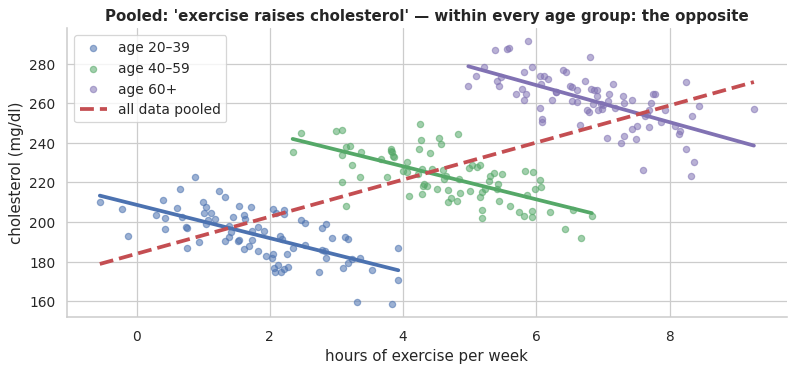

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.3))
xs, ys = [], []
for (age, x0, y0), col in zip([("age 20–39", 2, 190), ("age 40–59", 4.5, 225), ("age 60+", 7, 260)], [C[0], C[2], C[4]]):
    x = rng.normal(x0, 1.0, 80); y = y0 - 9 * (x - x0) + rng.normal(0, 9, 80)            # within each age group: exercise LOWERS cholesterol
    ax.scatter(x, y, color=col, alpha=.55, s=25, label=age)
    xx = np.array([x.min(), x.max()]); ax.plot(xx, np.polyval(np.polyfit(x, y, 1), xx), color=col, lw=3)
    xs.append(x); ys.append(y)
x, y = np.concatenate(xs), np.concatenate(ys); xx = np.array([x.min(), x.max()])
ax.plot(xx, np.polyval(np.polyfit(x, y, 1), xx), color=C[3], lw=3, ls="--", label="all data pooled")
ax.set(xlabel="hours of exercise per week", ylabel="cholesterol (mg/dl)", title="Pooled: 'exercise raises cholesterol' — within every age group: the opposite"); ax.legend()
plt.tight_layout(); plt.show()

---
## 3. Power analysis — how much data do I need?

From Module 6: **power** $=1-\beta$ is the probability that a study detects an effect *that really exists*. Four quantities are tied together — fix any three and the fourth follows:

$$\text{effect size} \quad\cdot\quad \text{sample size } n \quad\cdot\quad \text{significance level } \alpha \quad\cdot\quad \text{power}$$

For comparing two means with equal group sizes (two-sided $\alpha=0.05$, power 80 %):

$$n \text{ per group} \;=\; \frac{2\,(z_{1-\alpha/2}+z_{1-\beta})^2}{d^2} \;\approx\; \frac{16}{d^2} \qquad\text{with } d=\frac{\delta}{\sigma}\ \text{(Cohen's } d\text{)}$$

This is *Lehr's rule of 16*. Halving the effect you want to detect **quadruples** the required sample. The effect size to plug in is **not** the effect you hope for — it is the **minimum effect that would matter** (minimum detectable effect, MDE).

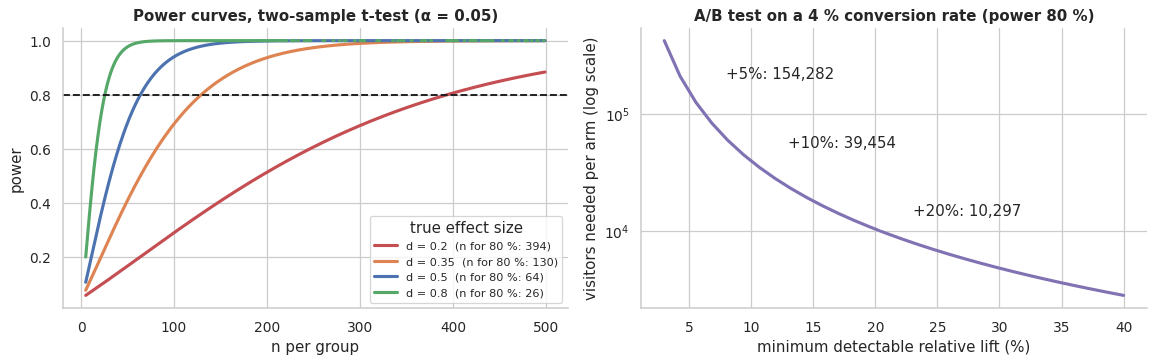

In [5]:
power_t, power_z = TTestIndPower(), NormalIndPower()
n = np.arange(5, 500)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
for d, col in zip([.2, .35, .5, .8], [C[3], C[1], C[0], C[2]]):
    a1.plot(n, power_t.power(effect_size=d, nobs1=n, alpha=.05), color=col, lw=2.5, label=f"d = {d}  (n for 80 %: {np.ceil(power_t.solve_power(d, power=.8, alpha=.05)):.0f})")
a1.axhline(.8, color="k", ls="--"); a1.set(xlabel="n per group", ylabel="power", title="Power curves, two-sample t-test (α = 0.05)"); a1.legend(title="true effect size", fontsize=9)

base = .04; lifts = np.linspace(.03, .40, 30)                                   # baseline conversion 4 %
need = [power_z.solve_power(proportion_effectsize(base * (1 + l), base), power=.8, alpha=.05) for l in lifts]
a2.plot(lifts * 100, need, color=C[4], lw=2.5); a2.set(yscale="log", xlabel="minimum detectable relative lift (%)", ylabel="visitors needed per arm (log scale)",
                                                       title="A/B test on a 4 % conversion rate (power 80 %)")
for l in [.05, .10, .20]:
    nn = power_z.solve_power(proportion_effectsize(base * (1 + l), base), power=.8, alpha=.05); a2.annotate(f"+{l:.0%}: {nn:,.0f}", (l * 100, nn), xytext=(l * 100 + 3, nn * 1.3), arrowprops=dict(arrowstyle="->"))
plt.tight_layout(); plt.show()

**Reading the figure.** *Left:* a "medium" effect ($d=0.5$) needs 64 per group, a "small" one ($d=0.2$) almost 400. *Right:* detecting a +5 % relative lift on a 4 % conversion rate needs on the order of 150,000 visitors per arm; a +20 % lift only about 10,000. **Decide the MDE with the business *before* the test** — it determines the duration.

---
## 4. The winner's curse — why underpowered studies exaggerate

Low power has a second, less known cost. If a study with low power *does* reach significance, the estimate **must** be far from zero — far larger than the truth — otherwise it would not have crossed the threshold. Significant results from small studies are therefore systematically **inflated** (type M error) and sometimes have the **wrong sign** (type S error).

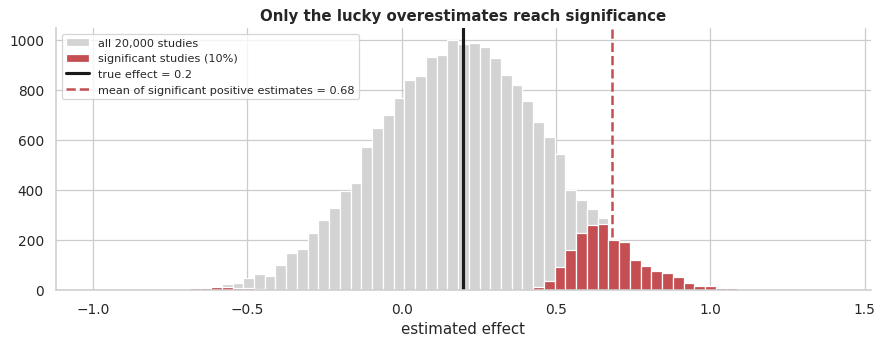

exaggeration factor among significant results: 3.4×;  wrong sign among significant results: 3.6%


In [6]:
R, n, d_true = 20_000, 25, .2                                  # true effect d = 0.2, n = 25 per group -> power only ~ 10 %
a, b = rng.normal(d_true, 1, (R, n)), rng.normal(0, 1, (R, n))
est = a.mean(axis=1) - b.mean(axis=1); sig = stats.ttest_ind(a, b, axis=1).pvalue < .05
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(-1, 1.4, 70)
ax.hist(est, bins=bins, color="lightgrey", label=f"all {R:,} studies"); ax.hist(est[sig], bins=bins, color=C[3], label=f"significant studies ({sig.mean():.0%})")
ax.axvline(d_true, color="k", lw=2.5, label="true effect = 0.2"); ax.axvline(est[sig & (est > 0)].mean(), color=C[3], ls="--", lw=2, label=f"mean of significant positive estimates = {est[sig & (est > 0)].mean():.2f}")
ax.set(xlabel="estimated effect", title="Only the lucky overestimates reach significance"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"exaggeration factor among significant results: {np.abs(est[sig]).mean() / d_true:.1f}×;  wrong sign among significant results: {(est[sig] < 0).mean():.1%}")

**Reading the figure.** The grey histogram is centred on the truth — the estimator is unbiased. But the *filter* "p < 0.05" lets only the extreme estimates through. If journals (or managers) only ever see the red studies, the literature (or the company's wiki of "proven wins") overstates effects several-fold. This is a core mechanism behind the **replication crisis** — and behind A/B-test wins that never show up in the quarterly numbers.

---
## 5. Multiple testing — the garden of forking paths

Run $m$ independent tests of true null hypotheses at $\alpha = 0.05$: the probability of **at least one** false positive (the *family-wise error rate*, FWER) is $1-(1-\alpha)^m$ — 40 % for 10 tests, 64 % for 20. Testing 20 metrics, 12 segments or 5 model variants is multiple testing, whether you write the tests down or not.

| Method | Controls | Rule | Character |
|---|---|---|---|
| **Bonferroni** | FWER | reject if $p_i \le \alpha/m$ | simple, conservative |
| **Holm** | FWER | sort p-values; compare $p_{(k)}$ with $\alpha/(m-k+1)$, stop at the first failure | uniformly better than Bonferroni — no reason not to use it |
| **Benjamini–Hochberg** | **FDR** = expected share of false discoveries among all discoveries | sort p-values; reject all up to the largest $k$ with $p_{(k)} \le \frac{k}{m}\alpha$ | much more powerful; standard for screening (genomics, many metrics) |

FWER control: "I want **no** false claim at all." FDR control: "I accept that about 5 % of my discoveries are false."

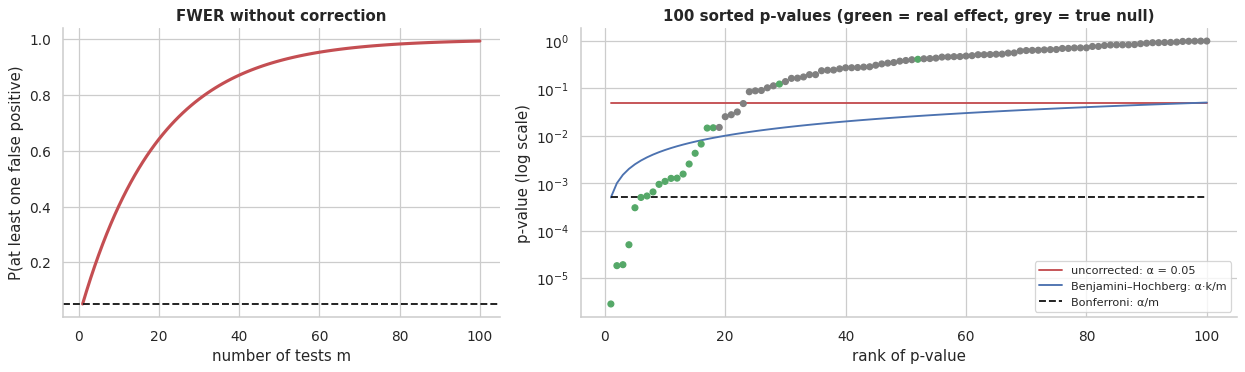

,discoveries,true positives,false positives,missed effects
none,23,18,5,2
bonferroni,6,6,0,14
holm,6,6,0,14
fdr_bh,16,16,0,4


In [7]:
m0, m1, n = 80, 20, 40                                            # 80 true nulls, 20 real effects (d = 0.7)
effects = np.r_[np.zeros(m0), np.full(m1, .7)]; is_real = effects > 0
pvals = np.array([stats.ttest_ind(rng.normal(e, 1, n), rng.normal(0, 1, n)).pvalue for e in effects])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.3), gridspec_kw={"width_ratios": [1, 1.5]})
m = np.arange(1, 101); a1.plot(m, 1 - .95 ** m, color=C[3], lw=2.5); a1.axhline(.05, color="k", ls="--")
a1.set(xlabel="number of tests m", ylabel="P(at least one false positive)", title="FWER without correction")
order = np.argsort(pvals); k = np.arange(1, pvals.size + 1)
a2.scatter(k, pvals[order], c=[C[2] if r else "grey" for r in is_real[order]], s=22, zorder=3)
a2.plot(k, np.full_like(k, .05, dtype=float), color=C[3], label="uncorrected: α = 0.05"); a2.plot(k, .05 * k / pvals.size, color=C[0], label="Benjamini–Hochberg: α·k/m")
a2.plot(k, np.full_like(k, .05 / pvals.size, dtype=float), color="k", ls="--", label="Bonferroni: α/m")
a2.set(yscale="log", xlabel="rank of p-value", ylabel="p-value (log scale)", title="100 sorted p-values (green = real effect, grey = true null)"); a2.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

rows = {}
for method in ["none", "bonferroni", "holm", "fdr_bh"]:
    rej = pvals < .05 if method == "none" else multipletests(pvals, alpha=.05, method=method)[0]
    rows[method] = {"discoveries": rej.sum(), "true positives": (rej & is_real).sum(), "false positives": (rej & ~is_real).sum(), "missed effects": (~rej & is_real).sum()}
pd.DataFrame(rows).T

**Reading the output.** Without correction we catch most real effects but also several false ones. Bonferroni/Holm eliminate the false positives at the price of missing many real effects. Benjamini–Hochberg sits in between: nearly the power of the uncorrected analysis with the false discoveries kept to a small share. Points *below* a line are rejected by that method.

**p-hacking** is multiple testing in disguise: trying several outcome definitions, outlier rules, covariate sets or subgroups and reporting the one that "worked". The defence is a **pre-specified analysis plan** with one primary metric.

---
## 6. Peeking — "is it significant yet?"

A fixed-sample test controls $\alpha$ **only if you look once**, at the planned sample size. Checking the dashboard daily and stopping as soon as $p<0.05$ is a multiple-testing problem in time: a p-value under $H_0$ wanders randomly, and given enough looks it will dip below 0.05 at some point.

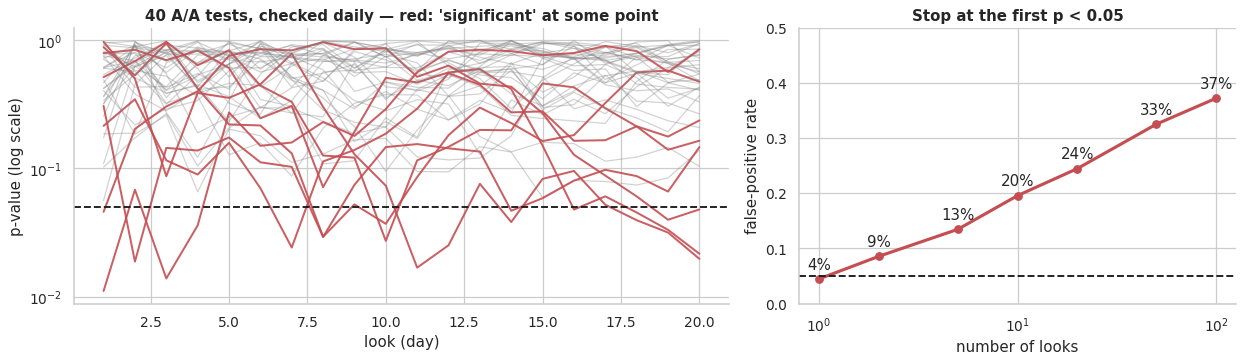

In [8]:
def simulate_aa(n_looks, n_per_look=200, R=5000):
    """A/A tests (no true difference): z-statistic of the cumulative data after each look."""
    a = rng.normal(0, np.sqrt(n_per_look), (R, n_looks)).cumsum(axis=1)       # cumulative sums of arm A (sum of n N(0,1) values ~ N(0, n))
    b = rng.normal(0, np.sqrt(n_per_look), (R, n_looks)).cumsum(axis=1)
    n_cum = n_per_look * np.arange(1, n_looks + 1)
    return 2 * stats.norm.sf(np.abs((a - b) / np.sqrt(2 * n_cum)))            # two-sided p-values, shape (R, n_looks)

p = simulate_aa(20)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
for path in p[:40]:
    hit = (path < .05).any()
    a1.plot(range(1, 21), path, color=C[3] if hit else "grey", alpha=.9 if hit else .35, lw=1.6 if hit else 1)
a1.axhline(.05, color="k", ls="--"); a1.set(yscale="log", xlabel="look (day)", ylabel="p-value (log scale)", title="40 A/A tests, checked daily — red: 'significant' at some point")
looks = [1, 2, 5, 10, 20, 50, 100]; fpr = [(simulate_aa(L) < .05).any(axis=1).mean() for L in looks]
a2.plot(looks, fpr, "o-", color=C[3], lw=2.5); a2.axhline(.05, color="k", ls="--")
for L, f in zip(looks, fpr): a2.annotate(f"{f:.0%}", (L, f), xytext=(0, 8), textcoords="offset points", ha="center")
a2.set(xscale="log", xlabel="number of looks", ylabel="false-positive rate", ylim=(0, .5), title="Stop at the first p < 0.05")
plt.tight_layout(); plt.show()

**Reading the figure.** With 10 looks the false-positive rate is about 19 % instead of 5 %, with daily peeks over several weeks a quarter to a third of all A/A tests "win". **Remedies:**
1. **Fixed horizon:** compute $n$ in advance, look once. (Monitoring for *bugs* is fine; stopping for *significance* is not.)
2. **Group-sequential designs:** a few planned interim looks with stricter thresholds (Pocock: same threshold at each look; O'Brien–Fleming: very strict early, nearly 0.05 at the end).
3. **Always-valid inference** (sequential tests, e.g. mSPRT) — used by several commercial experimentation platforms.

---
## 7. Variance reduction — more power without more users

Power depends on the **noise** as much as on $n$. Two design tools reduce noise:

* **Blocking / pairing / stratification** — compare like with like (Module 6: paired test). Randomise *within* homogeneous blocks.
* **Covariate adjustment (CUPED — *Controlled-experiment Using Pre-Experiment Data*)** — subtract the part of the outcome that was predictable *before* the experiment started:

$$Y^{cv}_i = Y_i - \theta\,(X_i-\bar X), \qquad \theta = \frac{\operatorname{Cov}(X,Y)}{\operatorname{Var}(X)}, \qquad \operatorname{Var}(Y^{cv}) = (1-\rho^2)\operatorname{Var}(Y)$$

$X$ must be measured **before** treatment (e.g. last month's spend), so it cannot be affected by it. The treatment-effect estimate stays unbiased; its variance shrinks by the factor $1-\rho^2$. With $\rho = 0.8$ that is like getting almost three times the traffic for free.

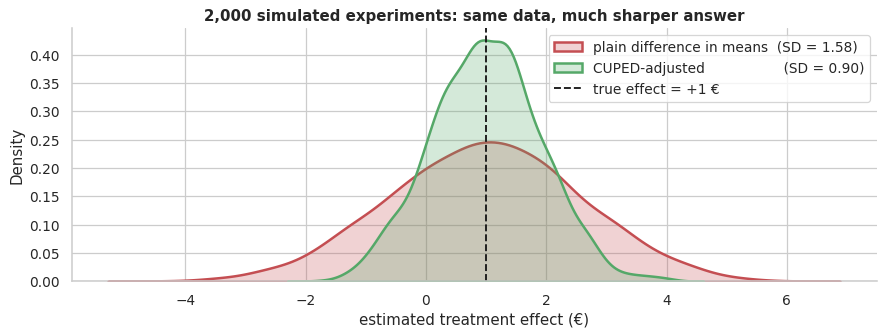

In [9]:
def one_experiment(n=1000, effect=1.0):
    x = rng.gamma(2, 25, 2 * n)                                                # pre-experiment spend (€)
    t = rng.permutation(np.r_[np.zeros(n), np.ones(n)]).astype(bool)           # random assignment
    y = 10 + .8 * x + rng.normal(0, 20, 2 * n) + effect * t                    # spend during the experiment; true effect = +1 €
    theta = np.cov(x, y)[0, 1] / x.var(ddof=1)
    y_cv = y - theta * (x - x.mean())
    return y[t].mean() - y[~t].mean(), y_cv[t].mean() - y_cv[~t].mean()

est = np.array([one_experiment() for _ in range(2000)])
fig, ax = plt.subplots(figsize=(10, 3.9))
sns.kdeplot(est[:, 0], ax=ax, color=C[3], fill=True, lw=2, label=f"plain difference in means  (SD = {est[:, 0].std():.2f})")
sns.kdeplot(est[:, 1], ax=ax, color=C[2], fill=True, lw=2, label=f"CUPED-adjusted                  (SD = {est[:, 1].std():.2f})")
ax.axvline(1, color="k", ls="--", label="true effect = +1 €"); ax.set(xlabel="estimated treatment effect (€)", title="2,000 simulated experiments: same data, much sharper answer"); ax.legend()
plt.tight_layout(); plt.show()

---
## 8. Regression to the mean — the effect that isn't

Whenever you **select units because of an extreme measurement** and measure again, the second measurement will on average be *less extreme* — without any intervention. Reason: an extreme value is partly signal and partly luck, and luck does not repeat. With test–retest correlation $r$, the expected second score is $\;\mu + r\,(x_1-\mu)$.

Victims of this fallacy: "the worst-performing stores improved after our coaching", "patients recruited at the peak of their symptoms got better", "praise makes pilots worse, criticism makes them better" (Kahneman's flight instructors), the "sophomore slump".

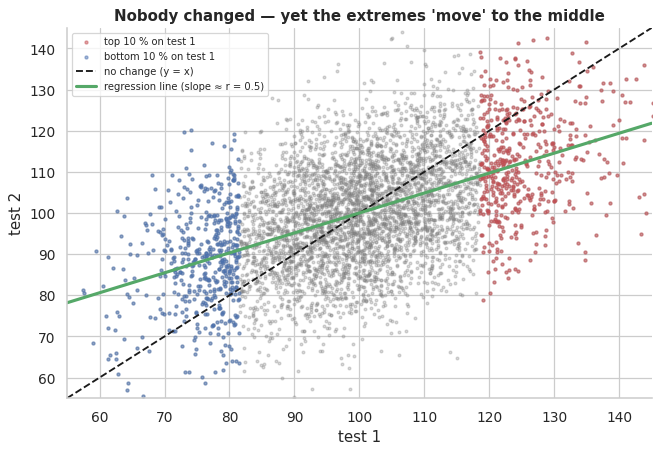

top 10 %   : test 1 mean = 125.6  ->  test 2 mean = 113.1
bottom 10 %: test 1 mean = 75.1  ->  test 2 mean = 88.1


In [10]:
skill = rng.normal(100, 10, 5000)
test1, test2 = skill + rng.normal(0, 10, 5000), skill + rng.normal(0, 10, 5000)           # same skill, fresh luck
top = test1 >= np.quantile(test1, .90); bottom = test1 <= np.quantile(test1, .10)
fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.scatter(test1, test2, s=5, color="grey", alpha=.3); ax.scatter(test1[top], test2[top], s=6, color=C[3], alpha=.5, label="top 10 % on test 1"); ax.scatter(test1[bottom], test2[bottom], s=6, color=C[0], alpha=.5, label="bottom 10 % on test 1")
lim = np.array([55, 145]); ax.plot(lim, lim, "k--", label="no change (y = x)"); ax.plot(lim, np.polyval(np.polyfit(test1, test2, 1), lim), color=C[2], lw=2.5, label="regression line (slope ≈ r = 0.5)")
ax.set(xlabel="test 1", ylabel="test 2", xlim=lim, ylim=lim, title="Nobody changed — yet the extremes 'move' to the middle"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"top 10 %   : test 1 mean = {test1[top].mean():.1f}  ->  test 2 mean = {test2[top].mean():.1f}")
print(f"bottom 10 %: test 1 mean = {test1[bottom].mean():.1f}  ->  test 2 mean = {test2[bottom].mean():.1f}")

**The only reliable protection is a control group** that was selected in the same way but not treated: regression to the mean affects both groups equally and cancels in the comparison.

---
## 9. A checklist for trustworthy experiments

**Before**
1. One **primary metric**, one main hypothesis, direction and **MDE** agreed with the stakeholders.
2. **Power analysis** → sample size and run time (cover full weekly cycles).
3. **Unit of randomisation** = unit of analysis (users, not page views), assignment truly random and sticky.
4. Analysis plan written down: test, covariates (CUPED), segments, correction for multiple metrics.

**During**
5. Monitor for bugs and *sample-ratio mismatch* (is the split really 50/50? → $\chi^2$ test) — **not** for significance.

**After**
6. Analyse exactly as planned. Report **effect size + CI**, not just the p-value.
7. Treat unplanned segment findings as hypotheses for the next experiment.
8. Expect winners to shrink on roll-out (winner's curse); re-measure with a hold-out group if the stakes are high.

---
## 10. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 8.1 — *Simpson's paradox*: Was there gender bias in Berkeley's graduate admissions? (Real data, 1973)

In 1973 the University of California, Berkeley, feared a lawsuit: men were admitted to graduate school at a visibly higher rate than women. The data below covers the six largest departments (Bickel, Hammel & O'Connell, *Science* 1975).

**Tasks**
1. Compute the overall admission rate by gender.
2. Compute the admission rate by gender **within each department** and plot it.
3. Explain the contradiction: to which departments did women and men mainly apply, and how selective are those departments?
4. What is the right conclusion?

In [11]:
ucb = pd.DataFrame({"dept": list("ABCDEF") * 2, "gender": ["men"] * 6 + ["women"] * 6,
                    "admitted":   [512, 353, 120, 138, 53, 22,   89, 17, 202, 131, 94, 24],
                    "applicants": [825, 560, 325, 417, 191, 373, 108, 25, 593, 375, 393, 341]})
ucb

,dept,gender,admitted,applicants
0,A,men,512,825
1,B,men,353,560
2,C,men,120,325
3,D,men,138,417
4,E,men,53,191
5,F,men,22,373
6,A,women,89,108
7,B,women,17,25
8,C,women,202,593
9,D,women,131,375


In [12]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/08_experimental_design_power_pitfalls_solutions.ipynb`.

### ✍️ Exercise 8.2 — *Power analysis*: How long must the A/B test run? (Product experimentation)

Your shop converts **4.0 %** of visitors. The product team believes a new checkout could lift this to **4.4 %** and says smaller improvements are not worth the engineering effort. You get **6,000 visitors per day**, split 50/50.

**Tasks**
1. Required visitors per arm for $\alpha = 0.05$ (two-sided) and 80 % power — with `NormalIndPower` and with the formula $n = (z_{1-\alpha/2}+z_{1-\beta})^2\,[p_1(1-p_1)+p_2(1-p_2)]/\delta^2$.
2. How many days must the test run? (Round up to full weeks — why?)
3. The team is impatient and wants to stop after 7 days. What power would the test have?
4. What if the MDE were +0.2 percentage points instead? Plot power against run time for both MDEs.

In [13]:
p0, p1, daily_visitors = .040, .044, 6000

In [14]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/08_experimental_design_power_pitfalls_solutions.ipynb`.

### ✍️ Exercise 8.3 — *Multiple testing*: 25 segments, 6 "significant" results — how many are real? (Marketing analytics)

After an e-mail campaign test, an analyst compares treatment vs. control separately in 25 customer segments and proudly reports every segment with $p<0.05$. (In this simulation we know the truth: the campaign works in exactly three segments.)

**Tasks**
1. How many segments are "significant" without correction? How many false positives would you *expect* among 22 true nulls?
2. Apply Bonferroni, Holm and Benjamini–Hochberg. Tabulate true and false positives for each method.
3. Which method suits (i) a confirmatory claim to the board, (ii) an exploratory screening for follow-up tests?

In [15]:
g = np.random.default_rng(833)
segments = [f"S{i:02d}" for i in range(1, 26)]
true_effect = np.zeros(25); true_effect[[3, 11, 19]] = .22                     # the campaign only works in S04, S12, S20
pvals = pd.Series([stats.ttest_ind(g.normal(e, 1, 400), g.normal(0, 1, 400)).pvalue for e in true_effect], index=segments)
pvals.sort_values().head(8).round(4)

S12    0.0000
S20    0.0004
S04    0.0038
S09    0.0214
S23    0.0239
S24    0.0828
S06    0.1279
S05    0.1458
dtype: float64

In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/08_experimental_design_power_pitfalls_solutions.ipynb`.

### ✍️ Exercise 8.4 — *Peeking*: What does "we stop when it's significant" really cost? (Experimentation platform)

A team checks its A/B tests every morning for 14 days and stops as soon as $p<0.05$. You are given the z-statistics of 20,000 simulated **A/A tests** (no true effect) after each day.

**Tasks**
1. What is the false-positive rate if only the final analysis on day 14 counts?
2. What is it under the team's stop-at-first-significance policy?
3. On which days do the false alarms occur? Plot the distribution of the stopping day.
4. Find, by trial over a grid, the constant per-look significance level $\alpha^*$ (a *Pocock-type* boundary) that brings the overall false-positive rate back to 5 %.

In [17]:
g = np.random.default_rng(804)
R, looks, n_day = 20_000, 14, 500
cum_a = g.normal(0, np.sqrt(n_day), (R, looks)).cumsum(axis=1); cum_b = g.normal(0, np.sqrt(n_day), (R, looks)).cumsum(axis=1)
z = (cum_a - cum_b) / np.sqrt(2 * n_day * np.arange(1, looks + 1))            # z[i, d] = z-statistic of experiment i after day d+1
pvals = 2 * stats.norm.sf(np.abs(z)); pvals.shape

(20000, 14)

In [18]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/08_experimental_design_power_pitfalls_solutions.ipynb`.

### ✍️ Exercise 8.5 — *CUPED*: Sharpening an experiment with pre-period data (Online retail)

An experiment tested a new recommendation widget (2,000 users per arm). Outcome: spend during the 4-week test. For every user you also know the spend in the 4 weeks **before** the test.

**Tasks**
1. Estimate the treatment effect with a plain Welch $t$-test (estimate, 95 % CI, p-value).
2. Compute $\theta$ and the CUPED-adjusted outcome; repeat the analysis.
3. By how much did the CI shrink? Compare with the theoretical factor $\sqrt{1-\rho^2}$. How many users would the plain analysis need for the same precision?
4. Why must the covariate come from *before* the experiment?

In [19]:
g = np.random.default_rng(805)
n = 2000
pre = g.gamma(2, 30, 2 * n)
group = g.permutation(np.r_[np.zeros(n), np.ones(n)]).astype(int)
spend = (12 + .85 * pre + g.normal(0, 22, 2 * n) + 2.5 * group).round(2)      # true effect: +2.50 €
exp = pd.DataFrame({"group": np.where(group == 1, "treatment", "control"), "pre_spend": pre.round(2), "spend": spend})
exp.groupby("group")[["pre_spend", "spend"]].mean().round(2)

,pre_spend,spend
group,,
control,58.65,61.82
treatment,58.77,64.60


In [20]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/08_experimental_design_power_pitfalls_solutions.ipynb`.

### ✍️ Exercise 8.6 — *Regression to the mean*: Do speed cameras work? (Road-safety policy)

A region records accidents at 2,000 road sites. After year 1 it installs cameras at the **100 sites with the most accidents**. In year 2 accidents at those sites fall dramatically, and the press release writes itself. In this simulation the cameras have **no effect at all** — each site's underlying accident rate is identical in both years.

**Tasks**
1. Compute the mean accident count of the 100 camera sites in year 1 and in year 2, and the apparent reduction in %.
2. What happened at the other 1,900 sites?
3. Explain the result. How large is the correlation between year 1 and year 2?
4. Propose an evaluation design that would give an honest answer.

In [21]:
g = np.random.default_rng(806)
true_rate = g.gamma(4, 1.5, 2000)                                  # each site's long-run accident rate (mean 6 per year)
sites = pd.DataFrame({"year1": g.poisson(true_rate), "year2": g.poisson(true_rate)})
sites["camera"] = sites.year1.rank(method="first", ascending=False) <= 100
sites.describe().round(2)

,year1,year2
count,2000.00,2000.00
mean,6.09,6.04
std,3.93,3.90
min,0.00,0.00
25%,3.00,3.00
50%,5.00,5.00
75%,8.00,8.00
max,24.00,27.00


In [22]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/08_experimental_design_power_pitfalls_solutions.ipynb`.

---
## 11. 🔑 Key takeaways

* **Randomisation** balances measured *and unmeasured* confounders — the only route to causal claims that needs no untestable assumptions.
* **Simpson's paradox:** aggregate and subgroup comparisons can disagree; find out what determines the group sizes.
* **Power** links effect size, $n$, $\alpha$ and $\beta$; $n\approx16/d^2$ per group. Agree on the **MDE** first. Underpowered studies miss real effects *and* exaggerate the ones they find.
* $m$ tests → correct: **Holm** for confirmatory claims (FWER), **Benjamini–Hochberg** for screening (FDR).
* **Peeking** with optional stopping inflates false positives 3–6-fold. Fix the horizon or use sequential designs.
* **CUPED / blocking** buy power for free by removing predictable variance.
* Units selected for extreme values **regress to the mean** — always compare with a control group selected the same way.

### Cheat sheet
| Task | Code |
|---|---|
| sample size, two means | `TTestIndPower().solve_power(effect_size=d, power=.8, alpha=.05)` |
| sample size, two proportions | `NormalIndPower().solve_power(proportion_effectsize(p1, p0), power=.8, alpha=.05)` |
| power for given n | `TTestIndPower().power(effect_size=d, nobs1=n, alpha=.05)` |
| multiple-testing correction | `reject, p_adj, _, _ = multipletests(pvals, alpha=.05, method="holm")` (`"bonferroni"`, `"fdr_bh"`) |
| CUPED | `theta = np.cov(x, y)[0, 1] / x.var(ddof=1)`; `y_cv = y - theta * (x - x.mean())` |

**Next:** Module 9 — relationships between numeric variables: correlation and simple linear regression.